In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle competitions download -c nn-26-scene-style-classification
!unzip -q nn-26-scene-style-classification.zip -d /content/data

Saving kaggle.json to kaggle.json
 97% 1.12G/1.15G [00:07<00:00, 41.2MB/s]
100% 1.15G/1.15G [00:08<00:00, 154MB/s] 


## Imports & device

In [ ]:

import os, re, math, random, shutil, zipfile, json
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset, ConcatDataset
from torchvision import transforms
from torchvision.datasets import ImageFolder
from tqdm.auto import tqdm

import timm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", DEVICE)


Device: cuda


## File paths & counting samples in each class to check for imbalance

In [ ]:
DATA_DIR = '/content/data/StyleClassificationIndoors/StyleClassificationIndoors'
TRAIN_DIR = os.path.join(DATA_DIR, 'train')
TEST_DIR = os.path.join(DATA_DIR, 'test')
CLASS_MAP_PATH = os.path.join(DATA_DIR, 'class_mapping.txt')

assert os.path.exists(TRAIN_DIR), f"Train dir not found: {TRAIN_DIR}"
assert os.path.exists(TEST_DIR), f"Test dir not found: {TEST_DIR}"


classes = sorted([d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))])
counts = {c: len([f for f in os.listdir(os.path.join(TRAIN_DIR, c)) if f.lower().endswith(('jpg','jpeg','png','bmp','webp','tiff'))]) for c in classes}
print("Found classes:", len(classes))
for c in classes:
    print(f"  {c}: {counts[c]} images")
total_images = sum(counts.values())
print("Total train images:", total_images)

if os.path.exists(CLASS_MAP_PATH):
    print("\nFound class mapping file:", CLASS_MAP_PATH)
    class_map = {}
    with open(CLASS_MAP_PATH, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line: continue
            if '\t' in line:
                a,b = line.split('\t')[:2]
            elif ',' in line:
                a,b = line.split(',')[:2]
            else:
                parts = line.split()
                if len(parts) == 2:
                    a,b = parts
                else:
                    continue

            a = a.rstrip('.: ').strip()
            b = b.rstrip('.: ').strip()

            if a.isdigit():
                class_map[b] = int(a)
            elif b.isdigit():
                class_map[a] = int(b)
            else:
                class_map[a] = b
    print("Parsed class map entries:", len(class_map))
    # show sample
    for i, (k,v) in enumerate(class_map.items()):
        if i > 10: break
        print(f"  {k} -> {v}")
else:
    class_map = {}
    print("\nNo class mapping text file found at CLASS_MAP_PATH.")

Device: cuda
Found classes: 17
  asian: 779 images
  boho: 918 images
  coastal: 794 images
  contemporary: 782 images
  craftsman: 764 images
  eclectic: 809 images
  farmhouse: 795 images
  french-country: 788 images
  industrial: 764 images
  mediterranean: 789 images
  minimalist: 555 images
  modern: 809 images
  scandinavian: 768 images
  shabby-chic-style: 746 images
  southwestern: 772 images
  tropical: 772 images
  victorian: 759 images
Total train images: 13163

Found class mapping file: /content/data/StyleClassificationIndoors/StyleClassificationIndoors/class_mapping.txt
Parsed class map entries: 17
  asian -> 0
  boho -> 1
  coastal -> 2
  contemporary -> 3
  craftsman -> 4
  eclectic -> 5
  farmhouse -> 6
  french-country -> 7
  industrial -> 8
  mediterranean -> 9
  minimalist -> 10


In [ ]:
CFG = {
    'img_size': 224,
    'patch_size': 16,
    'in_chans': 3,
    'd_model': 768,
    'num_heads': 12,
    'mlp_ratio': 4.0,
    'num_layers': 12,
    'dropout': 0.0,
    'num_classes': len(classes),
    'batch_size': 32,
    'epochs': 50,
    'lr': 3e-5,
    'weight_decay': 1e-4,
    'num_workers': 0,
    'device': DEVICE
}

IMG_SIZE = CFG['img_size']
PATCH_SIZE = CFG['patch_size']
IN_CHANS = CFG['in_chans']
EMBED_DIM = CFG['d_model']
NUM_HEADS = CFG['num_heads']
MLP_RATIO = CFG['mlp_ratio']
NUM_LAYERS = CFG['num_layers']
NUM_CLASSES = CFG['num_classes']
BATCH_SIZE = CFG['batch_size']
EPOCHS = CFG['epochs']
LEARNING_RATE = CFG['lr']
WEIGHT_DECAY = CFG['weight_decay']
NUM_WORKERS = CFG['num_workers']
DEVICE = CFG['device']

print("CFG summary:")
for k,v in CFG.items():
    print(f" {k}: {v}")


CFG summary:
 img_size: 224
 patch_size: 16
 in_chans: 3
 d_model: 768
 num_heads: 12
 mlp_ratio: 4.0
 num_layers: 12
 dropout: 0.0
 num_classes: 17
 batch_size: 32
 epochs: 50
 lr: 3e-05
 weight_decay: 0.0001
 num_workers: 0
 device: cuda


# Augmentation

In [ ]:
from torchvision import transforms
from torchvision.transforms import InterpolationMode

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Validation / Inference Transform
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=InterpolationMode.BILINEAR),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

# color variation, geometry shifts, soft perspective, erasing
train_transform_strong = transforms.Compose([
    transforms.RandomResizedCrop(
        IMG_SIZE,
        scale=(0.6, 1.0),
        ratio=(0.9, 1.1),
        interpolation=InterpolationMode.BILINEAR
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.10),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(
        brightness=0.25,
        contrast=0.25,
        saturation=0.20,
        hue=0.03
    ),
    transforms.RandomPerspective(distortion_scale=0.30, p=0.35),
    transforms.AutoAugment(transforms.AutoAugmentPolicy.IMAGENET),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.07))
])

# Mild augmentation — applied to original images
# Adds diversity without destabilizing structure

train_transform_mild = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=InterpolationMode.BILINEAR),
    transforms.RandomHorizontalFlip(p=0.4),
    transforms.RandomRotation(degrees=6),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.12
    ),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

print("Transforms loaded: strong, mild, val")


Transforms loaded: strong, mild, val


In [ ]:
class TestImageDataset(Dataset):
    def __init__(self, test_dir, transform):
        self.paths = []
        for root, _, files in os.walk(test_dir):
            for f in files:
                if f.lower().endswith(('jpg','jpeg','png','bmp','webp','tiff')):
                    self.paths.append(os.path.join(root, f))
        self.paths = sorted(self.paths)
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        img = Image.open(path).convert('RGB')
        return self.transform(img), os.path.basename(path)

# ImageFolder automatically loads file paths and labels
train_dataset_full = ImageFolder(TRAIN_DIR, transform=train_transform_strong)
val_dataset_full   = ImageFolder(TRAIN_DIR, transform=val_transform)

print("Found classes:", train_dataset_full.classes)
print("Total images:", len(train_dataset_full))


Found classes: ['asian', 'boho', 'coastal', 'contemporary', 'craftsman', 'eclectic', 'farmhouse', 'french-country', 'industrial', 'mediterranean', 'minimalist', 'modern', 'scandinavian', 'shabby-chic-style', 'southwestern', 'tropical', 'victorian']
Total images: 13163


# Stratified Split : creating subsets of train and validation

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit

# Load dataset with augmentation for training
train_dataset_full = ImageFolder(TRAIN_DIR, transform=train_transform_strong)

# Validation dataset
val_dataset_full = ImageFolder(TRAIN_DIR, transform=val_transform)

# Extract labels from the ORIGINAL dataset
labels = np.array(train_dataset_full.targets)
indices = np.arange(len(labels))

sss = StratifiedShuffleSplit(
    n_splits=1,
    test_size=0.15,
    random_state=SEED
)

train_idx, val_idx = next(sss.split(indices, labels))

print("Total samples:", len(labels))
print("Train samples:", len(train_idx))
print("Val samples:", len(val_idx))

# Applying splits
train_subset = Subset(train_dataset_full, train_idx)
val_subset   = Subset(val_dataset_full,  val_idx)

print("Created stratified train and val subsets (recommended strong-only augmentation).")


Total samples: 13163
Train samples: 11188
Val samples: 1975
Created stratified train and val subsets (recommended strong-only augmentation).


# WeightedRandomSampler for **imbalance**

In [ ]:
from torch.utils.data import DataLoader, WeightedRandomSampler

BATCH_SIZE = 32

# Compute class weights
targets = labels[train_idx]
class_counts = np.bincount(targets)
class_weights = 1.0 / class_counts

# sample weight for each training sample
sample_weights = class_weights[targets]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("Dataloaders ready.")


Dataloaders ready.


# Vision Transformer implementation

In [ ]:
from einops import rearrange

class PatchEmbed(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=3, embed_dim=768):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.grid_size = (img_size // patch_size, img_size // patch_size)
        self.num_patches = self.grid_size[0] * self.grid_size[1]
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)  # (B, embed_dim, H/ps, W/ps)
        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)  # (B, num_patches, embed_dim)
        return x

class Attention(nn.Module):
    def __init__(self, dim, num_heads=8, qkv_bias=True, attn_drop=0., proj_drop=0.):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5
        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)

    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x)
        qkv = qkv.reshape(B, N, 3, self.num_heads, self.head_dim).permute(2,0,3,1,4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = (q @ k.transpose(-2,-1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)
        x = (attn @ v).transpose(1,2).reshape(B, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x

class Mlp(nn.Module):
    def __init__(self, in_features, hidden_features=None, out_features=None, act_layer=nn.GELU, drop=0.):
        super().__init__()
        out_features = out_features or in_features
        hidden_features = hidden_features or in_features
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = act_layer()
        self.fc2 = nn.Linear(hidden_features, out_features)
        self.drop = nn.Dropout(drop)
    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x

class Block(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4.0, drop=0., attn_drop=0.):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = Attention(dim, num_heads=num_heads, qkv_bias=True, attn_drop=attn_drop, proj_drop=drop)
        self.norm2 = nn.LayerNorm(dim)
        hidden_dim = int(dim * mlp_ratio)
        self.mlp = Mlp(in_features=dim, hidden_features=hidden_dim, out_features=dim, drop=drop)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

class ManualViT(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=3, num_classes=1000, embed_dim=768, depth=12, num_heads=12, mlp_ratio=4.0, drop_rate=0.):
        super().__init__()
        self.patch_embed = PatchEmbed(img_size=img_size, patch_size=patch_size, in_chans=in_chans, embed_dim=embed_dim)
        num_patches = self.patch_embed.num_patches
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.pos_drop = nn.Dropout(p=drop_rate)
        self.blocks = nn.ModuleList([Block(embed_dim, num_heads, mlp_ratio, drop=drop_rate) for _ in range(depth)])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)


        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, x):
        x = self.patch_embed(x)
        B = x.size(0)
        cls_token = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_token, x), dim=1)
        x = x + self.pos_embed
        x = self.pos_drop(x)
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)
        cls_out = x[:, 0]
        out = self.head(cls_out)
        return out

model = ManualViT(
    img_size=IMG_SIZE, patch_size=PATCH_SIZE, in_chans=IN_CHANS,
    num_classes=NUM_CLASSES, embed_dim=EMBED_DIM, depth=NUM_LAYERS,
    num_heads=NUM_HEADS, mlp_ratio=MLP_RATIO, drop_rate=CFG['dropout']
).to(DEVICE)

print("Manual ViT created. Parameter count:", sum(p.numel() for p in model.parameters() if p.requires_grad))


Manual ViT created. Parameter count: 85811729


In [ ]:
timm_name = 'vit_base_patch16_224'
print("Downloading timm model:", timm_name)
timm_model = timm.create_model(timm_name, pretrained=True)
timm_sd = timm_model.state_dict()

our_sd = model.state_dict()

matched = {}
not_matched = {}
for k, v in timm_sd.items():
    if k in our_sd and our_sd[k].shape == v.shape:
        matched[k] = v
    else:
        not_matched[k] = v

print(f"Direct matched keys: {len(matched)}, not matched: {len(not_matched)}")

new_sd = our_sd.copy()
for k,v in matched.items():
    new_sd[k] = v

heuristic_map = {
}

applied = 0
for k_t, v in list(not_matched.items()):
    if k_t in new_sd and new_sd[k_t].shape == v.shape:
        new_sd[k_t] = v
        applied += 1
        del not_matched[k_t]
        continue
    alt_keys = [
        k_t.replace('modules.', ''),
    ]
    found = False
    for alt in alt_keys:
        if alt in new_sd and new_sd[alt].shape == v.shape:
            new_sd[alt] = v
            applied += 1
            found = True
            break
    if found:
        del not_matched[k_t]

print("Heuristic-applied keys:", applied)
print("Remaining unmatched keys:", len(not_matched))

load_res = model.load_state_dict(new_sd, strict=False)
print("Load result:", load_res)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Direct matched keys: 150, not matched: 2
Heuristic-applied keys: 0
Remaining unmatched keys: 2
Load result: <All keys matched successfully>


# fine-tuning

In [ ]:
#freeze everything except head first, then unfreeze
def set_parameter_requires_grad(model, feature_extracting=True):
    if feature_extracting:
        for name, param in model.named_parameters():
            # keep head trainable
            if name.startswith('head'):
                param.requires_grad = True
            else:
                param.requires_grad = False
    else:
        for param in model.parameters():
            param.requires_grad = True

start_with_head_only = True
if start_with_head_only:
    set_parameter_requires_grad(model, feature_extracting=True)
    print("Parameters frozen except head. Trainable params:", sum(p.numel() for p in model.parameters() if p.requires_grad))
else:
    set_parameter_requires_grad(model, feature_extracting=False)
    print("All parameters trainable.")


Parameters frozen except head. Trainable params: 13073


# training setup

In [ ]:
import math
from torch.optim import AdamW

params_to_update = [p for p in model.parameters() if p.requires_grad]
optimizer = AdamW(params_to_update, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

def get_cosine_scheduler(optimizer, num_warmup_steps, num_training_steps, num_cycles=0.5, last_epoch=-1):
    def lr_lambda(current_step):
        if current_step < num_warmup_steps:
            return float(current_step) / float(max(1, num_warmup_steps))
        progress = float(current_step - num_warmup_steps) / float(max(1, num_training_steps - num_warmup_steps))
        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * num_cycles * 2.0 * progress)))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda, last_epoch)

total_steps_per_epoch = max(1, len(train_loader))
total_training_steps = total_steps_per_epoch * EPOCHS
warmup_steps = int(0.03 * total_training_steps)
scheduler = get_cosine_scheduler(optimizer, warmup_steps, total_training_steps)

criterion = nn.CrossEntropyLoss()
scaler = torch.cuda.amp.GradScaler() if DEVICE.type == 'cuda' else None

print("Optimizer & scheduler ready.")


Optimizer & scheduler ready.


/tmp/ipython-input-2228414626.py:24: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if DEVICE.type == 'cuda' else None


In [ ]:
def train_one_epoch(model, dataloader, criterion, optimizer, scaler, scheduler, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    pbar = tqdm(dataloader, desc='Train', leave=False)
    for step, (imgs, labels) in enumerate(pbar):
        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        if scaler is not None:
            with torch.cuda.amp.autocast():
                outputs = model(imgs)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        if scheduler is not None:
            scheduler.step()

        running_loss += loss.item() * imgs.size(0)
        _, preds = outputs.max(1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{100*correct/total:.2f}%'})

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

@torch.no_grad()
def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    for imgs, labels in tqdm(dataloader, desc='Val', leave=False):
        imgs = imgs.to(device)
        labels = labels.to(device)
        with torch.cuda.amp.autocast(enabled=(scaler is not None)):
            outputs = model(imgs)
            loss = criterion(outputs, labels)
        running_loss += loss.item() * imgs.size(0)
        _, preds = outputs.max(1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


In [ ]:
best_val = 0.0
history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}

phase1_epochs = 2 if start_with_head_only else 0
phase2_epochs = EPOCHS - phase1_epochs

print("Phase1 epochs (head-only):", phase1_epochs, "Phase2 epochs (full fine-tune):", phase2_epochs)

for epoch in range(1, phase1_epochs+1):
    print(f"Phase1 - Epoch {epoch}/{phase1_epochs}")
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, scaler, scheduler, DEVICE)
    val_loss, val_acc = validate(model, val_loader, criterion, DEVICE)
    history['train_loss'].append(tr_loss); history['train_acc'].append(tr_acc)
    history['val_loss'].append(val_loss); history['val_acc'].append(val_acc)
    print(f"Tr loss {tr_loss:.4f} tr acc {tr_acc:.4f} | Val loss {val_loss:.4f} val acc {val_acc:.4f}")
    if val_acc > best_val:
        best_val = val_acc
        torch.save(model.state_dict(), 'best_vit_finetuned_head.pth')
        print("Saved head-only best model")

#unfreeze and fine tune
print("Unfreezing all parameters for full fine-tune.")
set_parameter_requires_grad(model, feature_extracting=False)
optimizer = AdamW([p for p in model.parameters() if p.requires_grad], lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = get_cosine_scheduler(optimizer, warmup_steps, total_training_steps)

for epoch in range(1, phase2_epochs+1):
    print(f"Phase2 - Epoch {epoch}/{phase2_epochs}")
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, scaler, scheduler, DEVICE)
    val_loss, val_acc = validate(model, val_loader, criterion, DEVICE)
    history['train_loss'].append(tr_loss); history['train_acc'].append(tr_acc)
    history['val_loss'].append(val_loss); history['val_acc'].append(val_acc)
    print(f"Tr loss {tr_loss:.4f} tr acc {tr_acc:.4f} | Val loss {val_loss:.4f} val acc {val_acc:.4f}")
    if val_acc > best_val:
        best_val = val_acc
        torch.save(model.state_dict(), 'best_vit_finetuned_full.pth')
        print("Saved full fine-tuned best model")

print("Training complete. Best val acc:", best_val)


Phase1 epochs (head-only): 2 Phase2 epochs (full fine-tune): 48
Phase1 - Epoch 1/2


Train:   0%|          | 0/350 [00:00<?, ?it/s]

/tmp/ipython-input-3304568569.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Val:   0%|          | 0/62 [00:00<?, ?it/s]

/tmp/ipython-input-3304568569.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(scaler is not None)):


...

Val:   0%|          | 0/62 [00:00<?, ?it/s]

Tr loss 0.0131 tr acc 0.9967 | Val loss 2.8092 val acc 0.4699
Phase2 - Epoch 48/48


Train:   0%|          | 0/350 [00:00<?, ?it/s]

Val:   0%|          | 0/62 [00:00<?, ?it/s]

Tr loss 0.0160 tr acc 0.9947 | Val loss 2.8065 val acc 0.4699
Training complete. Best val acc: 0.4810126582278481
Final trained model saved to: vit_finetuned_FINAL.pth


# **EVALUATION**


=== Per-Class Accuracy ===
 0 | asian                | Acc:  48.72%  (57/117)
 1 | boho                 | Acc:  84.06%  (116/138)
 2 | coastal              | Acc:  39.50%  (47/119)
 3 | contemporary         | Acc:  30.77%  (36/117)
 4 | craftsman            | Acc:  43.48%  (50/115)
 5 | eclectic             | Acc:  47.54%  (58/122)
 6 | farmhouse            | Acc:  39.50%  (47/119)
 7 | french-country       | Acc:  40.68%  (48/118)
 8 | industrial           | Acc:  58.26%  (67/115)
 9 | mediterranean        | Acc:  42.37%  (50/118)
10 | minimalist           | Acc:  73.49%  (61/83)
11 | modern               | Acc:  33.06%  (40/121)
12 | scandinavian         | Acc:  45.22%  (52/115)
13 | shabby-chic-style    | Acc:  31.25%  (35/112)
14 | southwestern         | Acc:  51.72%  (60/116)
15 | tropical             | Acc:  51.72%  (60/116)
16 | victorian            | Acc:  38.60%  (44/114)


,Class Index,Class Name,Correct,Total,Accuracy (%)
0,0,asian,57,117,48.717949
1,1,boho,116,138,84.057971
2,2,coastal,47,119,39.495798
3,3,contemporary,36,117,30.769231
4,4,craftsman,50,115,43.478261
5,5,eclectic,58,122,47.540984
6,6,farmhouse,47,119,39.495798
7,7,french-country,48,118,40.677966
8,8,industrial,67,115,58.260870
9,9,mediterranean,50,118,42.372881


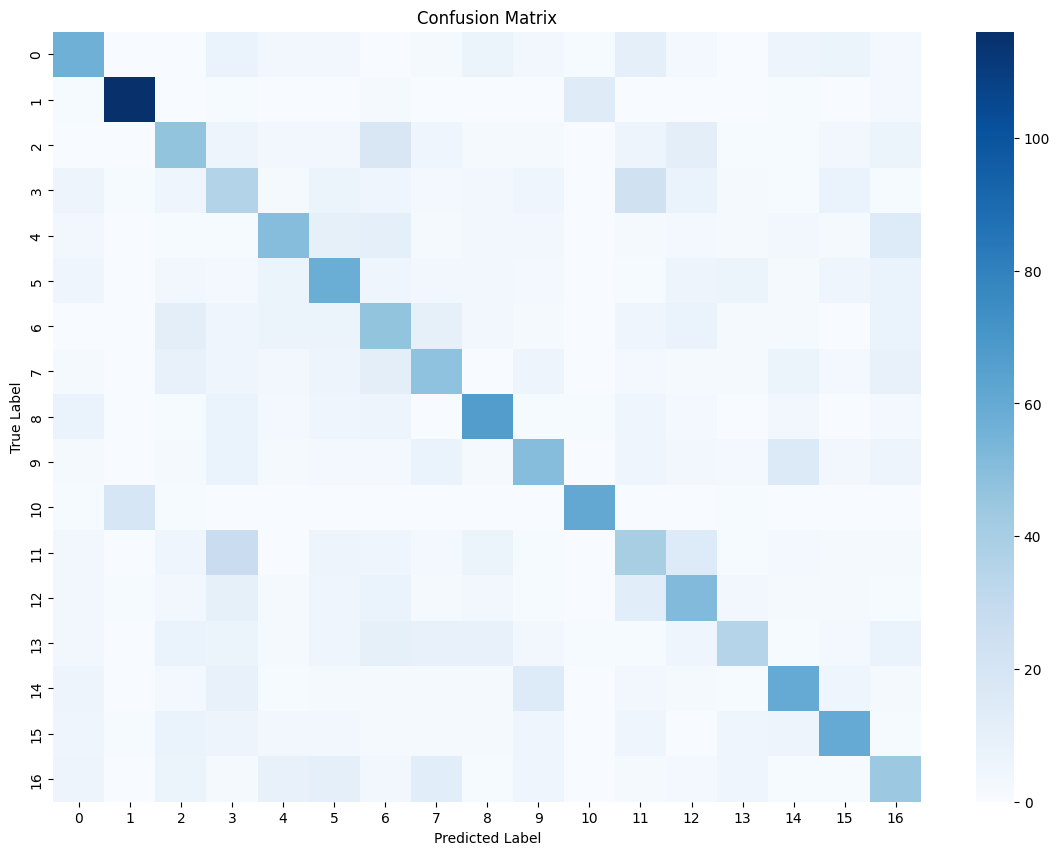

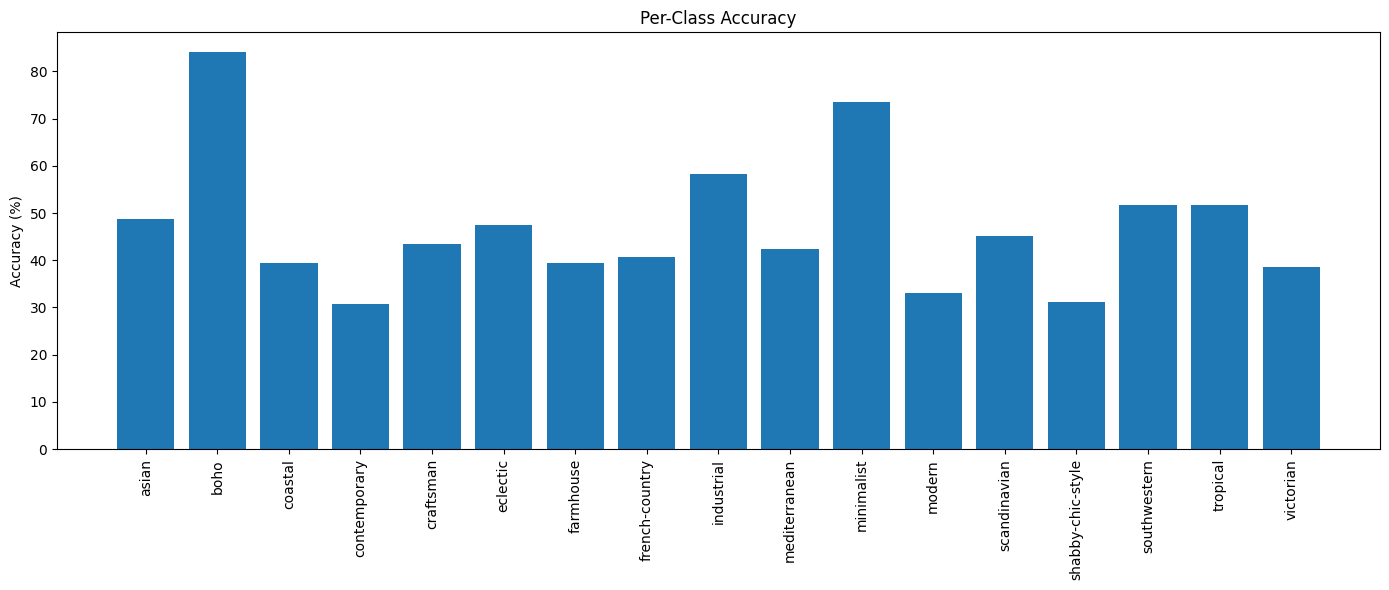

In [ ]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
from collections import defaultdict

model.eval()

correct_per_class = defaultdict(int)
total_per_class = defaultdict(int)

all_labels = []
all_preds = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(imgs)
        preds = outputs.argmax(dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

        for label, pred in zip(labels, preds):
            cls = int(label.item())
            total_per_class[cls] += 1
            if cls == int(pred.item()):
                correct_per_class[cls] += 1

class_to_idx = train_dataset_full.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx.items()}


# Per Class Acc
print("\n=== Per-Class Accuracy ===")
accuracies = []
for cls_idx in range(NUM_CLASSES):
    total = total_per_class[cls_idx]
    correct = correct_per_class[cls_idx]
    acc = correct / total if total > 0 else 0
    accuracies.append(acc)
    print(f"{cls_idx:2d} | {idx_to_class[cls_idx]:20s} | Acc: {acc*100:6.2f}%  ({correct}/{total})")


#Table
df = pd.DataFrame({
    "Class Index": list(range(NUM_CLASSES)),
    "Class Name": [idx_to_class[i] for i in range(NUM_CLASSES)],
    "Correct": [correct_per_class[i] for i in range(NUM_CLASSES)],
    "Total": [total_per_class[i] for i in range(NUM_CLASSES)],
    "Accuracy (%)": [a * 100 for a in accuracies]
})

display(df)


#Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


#Accuracy bar plot
plt.figure(figsize=(14, 6))
plt.bar([idx_to_class[i] for i in range(NUM_CLASSES)], [a * 100 for a in accuracies])
plt.xticks(rotation=90)
plt.ylabel("Accuracy (%)")
plt.title("Per-Class Accuracy")
plt.tight_layout()
plt.show()


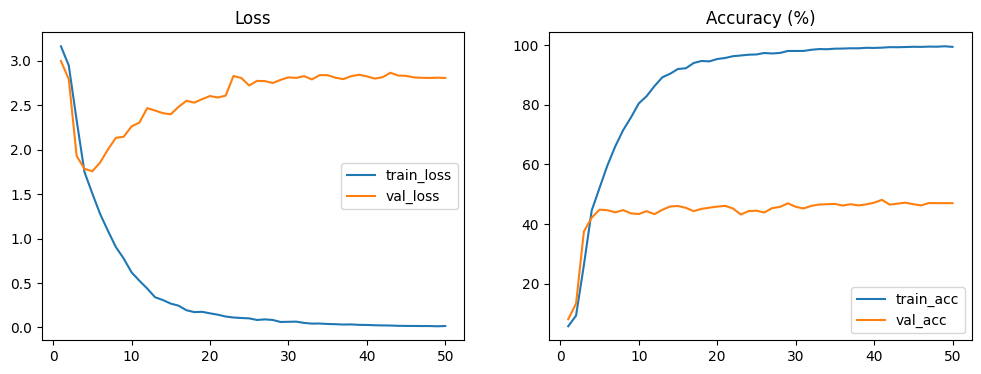

In [ ]:
import matplotlib.pyplot as plt
epochs = range(1, len(history['train_loss'])+1)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(epochs, history['train_loss'], label='train_loss')
plt.plot(epochs, history['val_loss'], label='val_loss')
plt.legend(); plt.title('Loss')

plt.subplot(1,2,2)
plt.plot(epochs, [a*100 for a in history['train_acc']], label='train_acc')
plt.plot(epochs, [a*100 for a in history['val_acc']], label='val_acc')
plt.legend(); plt.title('Accuracy (%)')
plt.show()


# load best model

In [ ]:
candidate_paths = ['best_vit_finetuned_full.pth', 'best_vit_finetuned_head.pth']
loaded = False
for p in candidate_paths:
    if os.path.exists(p):
        model.load_state_dict(torch.load(p, map_location=DEVICE))
        model.to(DEVICE)
        model.eval()
        print("Loaded", p)
        loaded = True
        break
if not loaded:
    print("No saved checkpoint found. Using current model weights.")


Loaded best_vit_finetuned_full.pth


In [ ]:
import os
import re
from PIL import Image, UnidentifiedImageError
import torch
import pandas as pd
from tqdm import tqdm

def extract_index(fname):
    m = re.search(r"(\d+)", fname)
    return int(m.group(1)) if m else None

all_paths = sorted(
    [os.path.join(TEST_DIR, f) for f in os.listdir(TEST_DIR) if f.lower().endswith(('.jpg', '.png', '.jpeg'))],
    key=lambda p: (extract_index(os.path.basename(p))
                   if extract_index(os.path.basename(p)) is not None else float('inf'))
)

pred_numbers = []

model.eval()

for path in tqdm(all_paths, desc="Inference"):
    try:

        img = Image.open(path).convert("RGB")
        img_t = val_transform(img).unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            logits = model(img_t)
            probs = torch.softmax(logits, dim=1)
            cls_idx = int(probs.argmax(dim=1).cpu().item())

        if class_map:
            cname = classes[cls_idx]
            num = class_map.get(cname, 0)
            pred_numbers.append(num)
        else:
            pred_numbers.append(cls_idx)

    except UnidentifiedImageError:
        print(f"[WARNING] Corrupted image detected: {os.path.basename(path)} — assigning label 0")
        pred_numbers.append(0)

    except Exception as e:
        print(f"[ERROR] {os.path.basename(path)} failed: {e} — assigning label 0")
        pred_numbers.append(0)

rows = []
for path, clsnum in zip(all_paths, pred_numbers):
    rows.append({
        "ImageName": os.path.basename(path),
        "ClassLabel": int(clsnum)
    })

df = pd.DataFrame(rows)

df["idx"] = df["ImageName"].apply(lambda x: extract_index(x) or 1_000_000)
df = df.sort_values("idx").drop(columns="idx").reset_index(drop=True)

OUT = "submission.csv"
df.to_csv(OUT, index=False)
print("Saved:", OUT)
print(df.head(10))


Inference:  34%|███▍      | 1888/5482 [00:47<01:24, 42.38it/s]

[WARNING] Corrupted image detected: testimage_1881.jpg — assigning label 0


Inference:  61%|██████    | 3348/5482 [01:24<00:44, 47.49it/s]

[WARNING] Corrupted image detected: testimage_3341.jpg — assigning label 0


Inference:  62%|██████▏   | 3409/5482 [01:25<00:45, 45.08it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Inference:  63%|██████▎   | 3436/5482 [01:26<00:42, 47.93it/s]

[WARNING] Corrupted image detected: testimage_3427.jpg — assigning label 0


Inference:  76%|███████▋  | 4186/5482 [01:44<00:35, 36.92it/s]

[WARNING] Corrupted image detected: testimage_4180.jpg — assigning label 0


Inference: 100%|██████████| 5482/5482 [02:16<00:00, 40.10it/s]


Saved: submission.csv
          ImageName  ClassLabel
0   testimage_1.jpg           6
1   testimage_2.jpg          10
2   testimage_3.jpg          10
3   testimage_4.jpg          10
4   testimage_5.jpg          10
5   testimage_6.jpg          10
6   testimage_7.jpg           2
7   testimage_8.jpg           7
8   testimage_9.jpg           7
9  testimage_10.jpg           9
